# NB10b — Explanation Faithfulness, Saturation-Free (CDTS Component c, rigorous re-do)

**Why a re-do:** NB10's insertion-deletion metric was confounded by score saturation
(start_score vs AUC r=0.998 -- high-competence detectors pin prob~1.0, compressing the metric).
The raw r=-0.93 flipped sign under different metrics -> NOT robust.

**The fix -- saturation-free faithfulness:** rank agreement between Grad-CAM importance and the
ACTUAL causal effect of removing each region. Partition image into an 8x8 grid (64 patches);
for each patch: importance = mean Grad-CAM, effect = prob_fake drop when ONLY that patch is
blurred. faithfulness = Spearman(importance, effect) across patches. Scale-free, no
absolute-score dependence -> sign is unambiguous.

**Test (across ALL ~21 generators):** does this faithfulness correlate with competence (AUC)?
- positive -> competent detectors have faithful explanations -> third pillar
- flat -> explanation faithfulness is competence-independent -> honest boundary finding
- (robustness: also a 4x4 grid; bootstrap CI over frames)

Per-generator checkpointing (saves after each method; re-run resumes).


## Cell 1 — Setup + load FS Xception

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, sys, glob, subprocess
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
PARENT = "/content/drive/MyDrive/CDTS_Research"
DFB = f"{REPO}/external/DeepfakeBench"
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"{PARENT}/{f}"): subprocess.run(f'cp "{PARENT}/{f}" /root/{f}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)
subprocess.run("pip -q install efficientnet_pytorch timm einops kornia simplejson", shell=True)
import importlib.util
for k in list(sys.modules.keys()):
    if k.startswith("detectors") or k.startswith("networks") or k=="metrics" or k.startswith("metrics.") or k=="inference":
        del sys.modules[k]
sys.path = [p for p in sys.path if p not in (f"{DFB}/training", f"{REPO}/src", DFB)]
sys.path.insert(0, DFB); sys.path.insert(0, f"{DFB}/training"); sys.path.append(f"{REPO}/src")
spec = importlib.util.spec_from_file_location("inference", f"{REPO}/src/inference.py")
inference = importlib.util.module_from_spec(spec); sys.modules["inference"]=inference
spec.loader.exec_module(inference)
model, device, info = inference.load_detector(dfb_root=DFB, backbone_name="xception",
    ckpt_path=f"{REPO}/weights/train_on_fs/xception.pth")
model.eval()
print("FS Xception load:", info, "device:", device)

Mounted at /content/drive
FS Xception load: {'missing': 0, 'unexpected': 0} device: cuda


## Cell 2 — Grad-CAM + saturation-free faithfulness metric

In [2]:
import torch, numpy as np, cv2
import torch.nn.functional as F
from scipy.stats import spearmanr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
MEAN = torch.tensor([0.5,0.5,0.5]).view(1,3,1,1).to(device)
STD  = torch.tensor([0.5,0.5,0.5]).view(1,3,1,1).to(device)

def load_img(path):
    im = cv2.imread(path)[:,:,::-1]
    im = cv2.resize(im,(256,256),interpolation=cv2.INTER_LINEAR)
    return im.astype(np.float32)/255.0
def to_tensor(im): return (torch.from_numpy(im).permute(2,0,1).unsqueeze(0).to(device)-MEAN)/STD

bb = model.backbone
target_layer = dict(bb.named_modules())['conv4']

def grad_cam(im):
    acts={};grads={}
    def fh(m,i,o):acts['a']=o
    def bh(m,gi,go):grads['g']=go[0]
    h1=target_layer.register_forward_hook(fh);h2=target_layer.register_full_backward_hook(bh)
    x=to_tensor(im).requires_grad_(True)
    out=model({'image':x},inference=False)
    score=out['cls'][0,1]; model.zero_grad(); score.backward()
    A=acts['a'][0];G=grads['g'][0]
    w=G.mean(dim=(1,2));cam=F.relu((w.view(-1,1,1)*A).sum(0))
    cam=cam-cam.min();cam=cam/(cam.max()+1e-8)
    cam=F.interpolate(cam.view(1,1,8,8),size=(256,256),mode='bilinear',align_corners=False)[0,0]
    h1.remove();h2.remove()
    return cam.detach().cpu().numpy()

@torch.no_grad()
def prob_fake_of(im):
    out=model({'image':to_tensor(im)},inference=True)
    return float(out['prob']) if out['prob'].dim()==0 else float(out['prob'][0])

def faithfulness_rankcorr(im, cam, grid=8):
    # partition into grid x grid patches; importance = mean cam; effect = prob drop when patch blurred
    H,W = cam.shape; ph,pw = H//grid, W//grid
    blurred = cv2.GaussianBlur(im,(0,0),sigmaX=11)
    base = prob_fake_of(im)
    importance=[]; effect=[]
    for gy in range(grid):
        for gx in range(grid):
            y0,y1=gy*ph,(gy+1)*ph; x0,x1=gx*pw,(gx+1)*pw
            importance.append(float(cam[y0:y1,x0:x1].mean()))
            tmp=im.copy(); tmp[y0:y1,x0:x1,:]=blurred[y0:y1,x0:x1,:]
            effect.append(base - prob_fake_of(tmp))   # drop when this patch removed
    importance=np.array(importance); effect=np.array(effect)
    if importance.std()<1e-6 or effect.std()<1e-6: return np.nan
    return float(spearmanr(importance, effect).statistic)

print("Grad-CAM + saturation-free rank-correlation faithfulness ready")

Grad-CAM + saturation-free rank-correlation faithfulness ready


## Cell 3 — Faithfulness across ALL generators (checkpointed)

In [3]:
import pandas as pd, numpy as np, os, glob, zipfile, shutil
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
SHORTCUT = "/content/drive/MyDrive/CDTS_Research/DF40"
LOCALCORE = f"{REPO}/data/df40_core/test"
OUT = f"{REPO}/reports/calibration/explanation_faithfulness_rankcorr.csv"

tl = pd.read_csv(f"{REPO}/reports/calibration/timeline_df40_xceptionFS.csv")
ALL = tl.sort_values('AUC').method.tolist()   # all timeline generators, AUC-sorted
N_FRAMES = 30   # per generator (64 fwd passes each for 8x8)

# resume from checkpoint
done_methods = set()
if os.path.exists(OUT):
    prev = pd.read_csv(OUT); done_methods = set(prev.method)
    print(f"resuming: {len(done_methods)} generators already done")

def get_zip(m):
    for c in [f"{LOCALCORE}/{m}.zip", f"{SHORTCUT}/{m}.zip"]:
        if os.path.exists(c) and os.path.getsize(c)>1e6: return c
    return None

for method in ALL:
    if method in done_methods: continue
    auc = float(tl[tl.method==method].AUC.iloc[0])
    sp = f"{REPO}/reports/scores/xceptionFS_df40_{method}.parquet"
    if not os.path.exists(sp): print(f"{method}: no scores, skip"); continue
    zp = get_zip(method)
    if zp is None: print(f"{method}: no zip, skip"); continue
    print(f"=== {method} (AUC={auc:.3f}) ===")
    fakes = pd.read_parquet(sp); fakes = fakes[fakes.label==1]
    fdir=f"/content/xrc_{method}"; os.makedirs(fdir,exist_ok=True)
    try:
        with zipfile.ZipFile(zp) as z: z.extractall(fdir)
    except Exception as e:
        print(f"  unzip fail: {str(e)[:50]}"); shutil.rmtree(fdir,ignore_errors=True); continue
    fidx={"/".join(fp.split("/")[-2:]):fp for fp in glob.glob(f"{fdir}/**/*.png",recursive=True)}
    faiths=[]; done=0
    for _,r in fakes.sample(min(len(fakes),N_FRAMES*3),random_state=42).iterrows():
        fp=fidx.get("/".join(str(r['frame_path']).split("/")[-2:]))
        if not fp or not os.path.exists(fp): continue
        try:
            im=load_img(fp); cam=grad_cam(im); f8=faithfulness_rankcorr(im,cam,grid=8)
            if not np.isnan(f8): faiths.append(f8); done+=1
            if done>=N_FRAMES: break
        except Exception: continue
    shutil.rmtree(fdir,ignore_errors=True)
    if faiths:
        row = {"method":method,"AUC":auc,"n_frames":len(faiths),
               "faithfulness_rankcorr":float(np.mean(faiths)),"faith_std":float(np.std(faiths))}
        # append to checkpoint immediately
        hdr = not os.path.exists(OUT)
        pd.DataFrame([row]).to_csv(OUT, mode='a', header=hdr, index=False)
        print(f"  faithfulness(rankcorr)={np.mean(faiths):.4f} (n={len(faiths)}) -> saved")

print("\n=== all done ===")
fa = pd.read_csv(OUT)
print(fa.sort_values('AUC').to_string(index=False))

=== sadtalker (AUC=0.427) ===
  faithfulness(rankcorr)=0.1162 (n=30) -> saved
=== pixart (AUC=0.433) ===
  faithfulness(rankcorr)=0.1267 (n=30) -> saved
=== wav2lip (AUC=0.470) ===
  faithfulness(rankcorr)=0.1078 (n=30) -> saved
=== DiT (AUC=0.521) ===
  faithfulness(rankcorr)=0.3478 (n=30) -> saved
=== SiT (AUC=0.553) ===
  faithfulness(rankcorr)=0.2952 (n=30) -> saved
=== lia (AUC=0.607) ===
  faithfulness(rankcorr)=0.1533 (n=30) -> saved
=== StyleGANXL (AUC=0.637) ===
  faithfulness(rankcorr)=0.2023 (n=30) -> saved
=== StyleGAN2 (AUC=0.649) ===
  faithfulness(rankcorr)=0.3235 (n=30) -> saved
=== StyleGAN3 (AUC=0.679) ===
  faithfulness(rankcorr)=0.3809 (n=30) -> saved
=== sd2.1 (AUC=0.688) ===
  faithfulness(rankcorr)=0.3523 (n=30) -> saved
=== pirender (AUC=0.688) ===
  faithfulness(rankcorr)=0.2681 (n=30) -> saved
rddm: no zip, skip
=== ddim (AUC=0.766) ===
  faithfulness(rankcorr)=0.4881 (n=30) -> saved
=== fomm (AUC=0.801) ===
  faithfulness(rankcorr)=0.5079 (n=30) -> saved
=== 

## Cell 4 — THE ROBUST TEST: saturation-free faithfulness vs competence

In [4]:
import pandas as pd, numpy as np
from scipy.stats import pearsonr, spearmanr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
fa = pd.read_csv(f"{REPO}/reports/calibration/explanation_faithfulness_rankcorr.csv").dropna(subset=['AUC','faithfulness_rankcorr'])

r,p = pearsonr(fa.AUC, fa.faithfulness_rankcorr)
rs,ps = spearmanr(fa.AUC, fa.faithfulness_rankcorr)
print(f"=== saturation-free faithfulness vs competence ({len(fa)} generators) ===")
print(f"  Pearson r={r:.3f} (p={p:.4f}), Spearman={rs:.3f} (p={ps:.4f})")
print()
print(fa.sort_values('AUC')[['method','AUC','faithfulness_rankcorr','n_frames']].to_string(index=False))
print()
if p < 0.05 and r > 0.4:
    print(">>> ROBUST: faithfulness RISES with competence (saturation-free metric).")
    print("    Competent detectors -> faithful explanations. THIRD PILLAR confirmed; competence")
    print("    organizes calibration (a), monitoring (d), AND explanation faithfulness (c).")
elif p < 0.05 and r < -0.4:
    print(">>> ROBUST but NEGATIVE: faithfulness FALLS with competence even saturation-free.")
    print("    Needs interpretation -- low-competence detectors have higher importance-effect agreement.")
else:
    print(">>> NO robust coupling: explanation faithfulness is competence-INDEPENDENT under the")
    print("    saturation-free metric. Honest boundary finding -- not all trust signals couple to")
    print("    competence. The raw insertion-deletion r=-0.93 was a saturation artifact.")

=== saturation-free faithfulness vs competence (20 generators) ===
  Pearson r=0.936 (p=0.0000), Spearman=0.929 (p=0.0000)

     method    AUC  faithfulness_rankcorr  n_frames
  sadtalker 0.4270               0.116184        30
     pixart 0.4329               0.126700        30
    wav2lip 0.4701               0.107833        30
        DiT 0.5214               0.347835        30
        SiT 0.5535               0.295162        30
        lia 0.6068               0.153264        30
 StyleGANXL 0.6374               0.202304        30
  StyleGAN2 0.6491               0.323517        30
  StyleGAN3 0.6792               0.380909        30
      sd2.1 0.6879               0.352305        30
   pirender 0.6880               0.268066        30
       ddim 0.7661               0.488148        30
       fomm 0.8008               0.507902        30
     inswap 0.8152               0.456954        30
facevid2vid 0.8216               0.633436        30
   faceswap 0.8919               0.603963   

## Cell 5 — Figure + commit

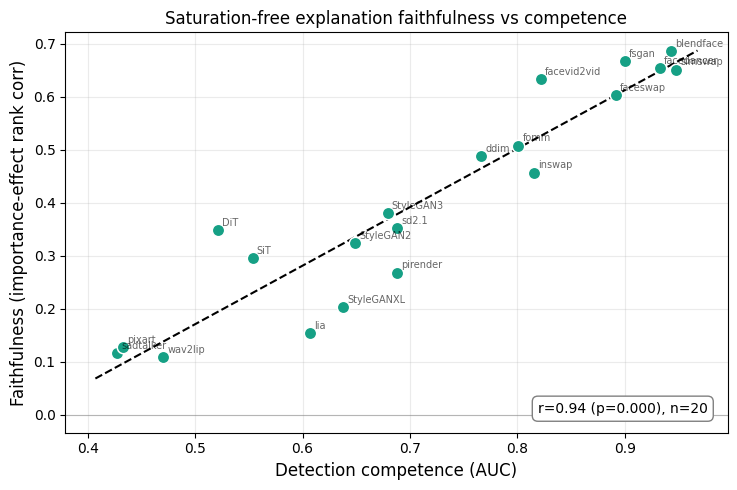

saved: /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/explanation_faithfulness_rankcorr.png
 m external/DeepfakeBench
A  figures/explanation_faithfulness_rankcorr.png
A  figures/explanation_faithfulness_vs_competence.png
 M notebooks/NB06_effnet_df40.ipynb
 M notebooks/NB08_timeline_scoring.ipynb
 M notebooks/NB09_labelfree_competence.ipynb
AM notebooks/NB10_explanation_stability.ipynb
AM notebooks/NB10b_explanation_rankcorr.ipynb
A  reports/calibration/explanation_faithfulness.csv
A  reports/calibration/explanation_faithfulness_rankcorr.csv
 M src/inference.py

>>> review, then commit with the ROBUST verdict


In [5]:
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
fa = pd.read_csv(f"{REPO}/reports/calibration/explanation_faithfulness_rankcorr.csv").dropna(subset=['AUC','faithfulness_rankcorr'])

fig,ax=plt.subplots(figsize=(7.5,5))
ax.scatter(fa.AUC, fa.faithfulness_rankcorr, s=80, c="#16A085", edgecolor="white", linewidth=1.1, zorder=3)
for _,r in fa.iterrows():
    ax.annotate(r['method'],(r['AUC'],r['faithfulness_rankcorr']),fontsize=7,alpha=0.6,xytext=(3,3),textcoords='offset points')
x,y=fa.AUC.values,fa.faithfulness_rankcorr.values
b,a=np.polyfit(x,y,1);xs=np.linspace(x.min()-.02,x.max()+.02,100)
ax.plot(xs,a+b*xs,"k--",lw=1.5)
rr,pp=pearsonr(x,y)
ax.annotate(f"r={rr:.2f} (p={pp:.3f}), n={len(fa)}",xy=(.97,.05),xycoords="axes fraction",ha="right",fontsize=10,bbox=dict(boxstyle="round,pad=0.4",fc="white",ec="gray"))
ax.axhline(0,color='gray',lw=0.8,alpha=0.5)
ax.set_xlabel("Detection competence (AUC)",fontsize=12)
ax.set_ylabel("Faithfulness (importance-effect rank corr)",fontsize=12)
ax.set_title("Saturation-free explanation faithfulness vs competence",fontsize=12)
ax.grid(True,alpha=0.25);plt.tight_layout()
out=f"{REPO}/figures/explanation_faithfulness_rankcorr.png"
plt.savefig(out,dpi=300,bbox_inches="tight");plt.show()
print("saved:",out)

import subprocess
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git add reports/calibration/explanation_faithfulness_rankcorr.csv figures/explanation_faithfulness_rankcorr.png notebooks/NB10b_explanation_rankcorr.ipynb", shell=True)
r=subprocess.run("git status --short",shell=True,capture_output=True,text=True)
print(r.stdout); print(">>> review, then commit with the ROBUST verdict")